# [Evaluations](https://wikidocs.net/259203)

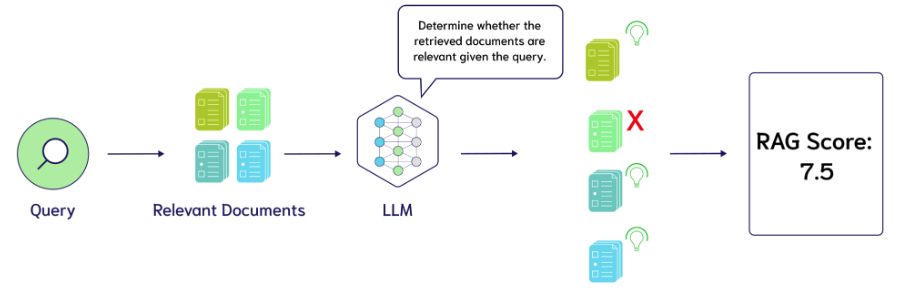

# [RAGAs - Evaluations](https://docs.ragas.io/en/stable/)

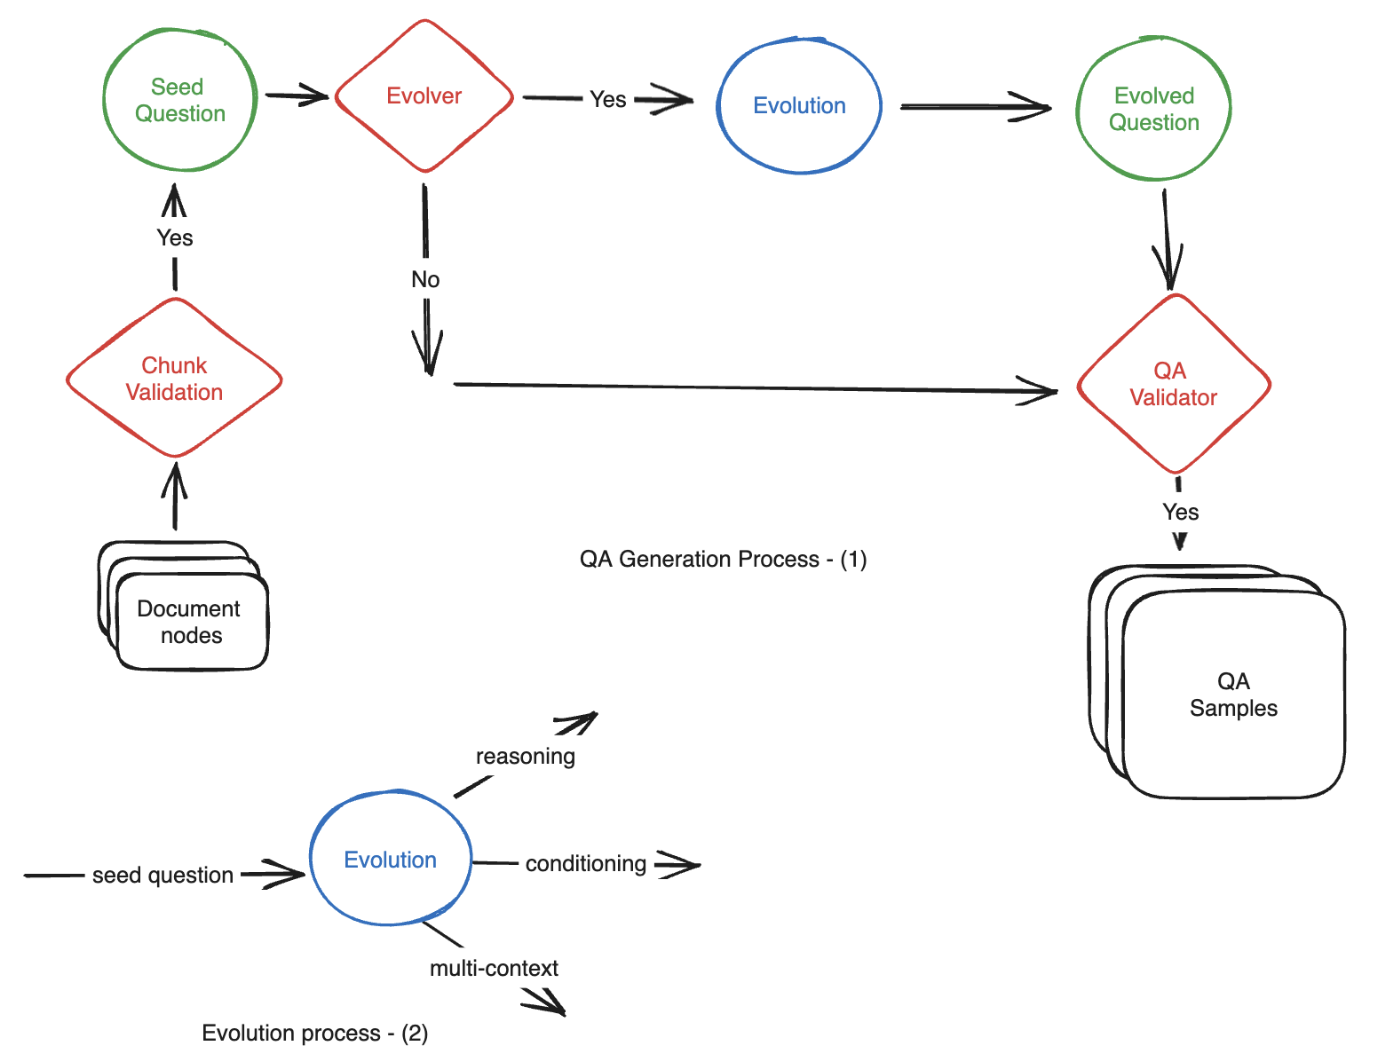

## RAG

### 단계 1: 문서 로드(Load Documents)

In [1]:
from langchain_community.document_loaders import PDFPlumberLoader

loader = PDFPlumberLoader("./data/SPRI_AI_Brief_2023년12월호_F.pdf")
docs = loader.load()

In [2]:
print(f"pdf 페이지 수: {len(docs)}")

pdf 페이지 수: 23


### 단계 2: 문서 분할(Split Documents)

In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500, chunk_overlap=50)
split_documents = text_splitter.split_documents(docs)

In [4]:
print(f"저장될 문서의 수: {len(split_documents)}")

저장될 문서의 수: 72


### 단계 3: 임베딩(Embedding) 생성

In [6]:
from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv 

load_dotenv()
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

### 단계 4: DB 생성(Create DB) 및 저장

In [7]:
from langchain.vectorstores import Chroma

vectorstore = Chroma.from_documents(
    documents=split_documents, # 문서 리스트
    embedding=embeddings, # 임베딩 함수
    collection_name="evaluation", # 컬렉션 이름
    persist_directory="./chroma_evaluation" # 영구 저장 경로
)

In [8]:
stats = vectorstore._collection.count()

print(f"현재 문서 수: {stats}")

현재 문서 수: 72


### 단계 5: 검색기(Retriever) 생성

In [9]:
# 문서에 포함되어 있는 정보를 검색하고 생성합니다.
retriever = vectorstore.as_retriever()

### 단계 6: 프롬프트 생성(Create Prompt)

In [10]:
from langchain_core.prompts import PromptTemplate

# 프롬프트를 생성합니다.
prompt = PromptTemplate.from_template(
    template="""
    - You are an assistant for question-answering tasks.
    - Use the following pieces of retrieved context to answer the question.
    - If you don't know the answer, just say that you don't know.
    - you have to answer in Korean.

    #Context:
    {context}

    #Question:
    {question}
    """
)

In [11]:
prompt.input_variables

['context', 'question']

### 단계7: RAG 체인 생성
- LLM을 통한 답변 생성

In [12]:
from langchain_openai import ChatOpenAI

# 언어모델(LLM) 생성
llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)

In [13]:
from langchain_core.output_parsers import StrOutputParser

def get_answer_of_llm(dict_param:dict):
    contexts = [
        doc.page_content for doc in dict_param["context"]
    ]

    answer = (prompt | llm | StrOutputParser()).invoke({
        "context" : "\n".join(contexts),
        "question": dict_param["question"]
    })

    return {
        "context": contexts,
        "question": dict_param["question"],
        "answer": answer
    }

from langchain_core.runnables import RunnablePassthrough, RunnableLambda

chain = (
    {
        "context": retriever, 
        "question": RunnablePassthrough()
    }
    | RunnableLambda(get_answer_of_llm)
)

    

In [14]:

from langchain_core.runnables import RunnablePassthrough, RunnableLambda

chain = (
    {
        "context": retriever, 
        "question": RunnablePassthrough()
    }
    | RunnableLambda(get_answer_of_llm)
)


### 단계8: 답변 추가 및 저장

- evaluation_ragas 데이터 로드 

In [15]:
import pandas as pd 

df_evaluation_ragas = pd.read_csv("./data/evaluation_ragas.csv")
df_evaluation_ragas.shape 

(10, 3)

In [16]:
df_evaluation_ragas.head(2)

,user_input,reference_contexts,reference
0,AI의 안전하고 신뢰할 수 있는 개발과 사용에 관한 행정명령은 무엇을 포함하나요?,"['1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하...","행정명령은 AI의 안전과 보안 기준 마련, 개인정보보호, 형평성과 시민권 향상, 소..."
1,독일은 G7의 AI 국제 행동강령에 어떤 역할을 하나요?,"['SPRi AI Brief |\n2023-12월호\nG7, 히로시마 AI 프로세스...","독일은 G7의 주요 7개국 중 하나로, 2023년 10월 30일 '히로시마 AI 프..."


- `batch()` 를 호출하여 배치 데이터셋에 대한 답변을 받습니다.

In [17]:
question_dataset = [question for question in df_evaluation_ragas["user_input"]]
question_dataset[:3]

['AI의 안전하고 신뢰할 수 있는 개발과 사용에 관한 행정명령은 무엇을 포함하나요?',
 '독일은 G7의 AI 국제 행동강령에 어떤 역할을 하나요?',
 '프랑스는 AI 안전성 정상회의에서 어떤 역할을 하였고, 그 결과로 무엇을 계획하고 있나요?']

In [18]:
results = chain.batch(question_dataset)

In [19]:
type(results[0]['context'])

list

In [20]:
df_evaluation_ragas['answer'] = [ result['answer'] for result in results ]
df_evaluation_ragas['contexts'] = [ result['context'] for result in results ]

df_evaluation_ragas = df_evaluation_ragas.rename(
    columns={"user_input":"question", "reference":"ground_truth"}
)

df_evaluation_ragas.head(2)

,question,reference_contexts,ground_truth,answer,contexts
0,AI의 안전하고 신뢰할 수 있는 개발과 사용에 관한 행정명령은 무엇을 포함하나요?,"['1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하...","행정명령은 AI의 안전과 보안 기준 마련, 개인정보보호, 형평성과 시민권 향상, 소...",다음과 같이 요약됩니다.\n\n- 안전 및 보안 기준 마련: AI의 안전성과 신뢰성...,"[1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하고..."
1,독일은 G7의 AI 국제 행동강령에 어떤 역할을 하나요?,"['SPRi AI Brief |\n2023-12월호\nG7, 히로시마 AI 프로세스...","독일은 G7의 주요 7개국 중 하나로, 2023년 10월 30일 '히로시마 AI 프...","독일은 G7의 구성국으로서, 2023년 히로시마 AI 프로세스를 통해 합의된 AI ...","[SPRi AI Brief |\n2023-12월호\nG7, 히로시마 AI 프로세스를..."


In [21]:
df_evaluation_ragas_with_answer = df_evaluation_ragas[['question', 'contexts', 'answer', 'ground_truth']]

In [22]:
df_evaluation_ragas_with_answer.head(2)

,question,contexts,answer,ground_truth
0,AI의 안전하고 신뢰할 수 있는 개발과 사용에 관한 행정명령은 무엇을 포함하나요?,"[1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하고...",다음과 같이 요약됩니다.\n\n- 안전 및 보안 기준 마련: AI의 안전성과 신뢰성...,"행정명령은 AI의 안전과 보안 기준 마련, 개인정보보호, 형평성과 시민권 향상, 소..."
1,독일은 G7의 AI 국제 행동강령에 어떤 역할을 하나요?,"[SPRi AI Brief |\n2023-12월호\nG7, 히로시마 AI 프로세스를...","독일은 G7의 구성국으로서, 2023년 히로시마 AI 프로세스를 통해 합의된 AI ...","독일은 G7의 주요 7개국 중 하나로, 2023년 10월 30일 '히로시마 AI 프..."


In [26]:
import json

df_evaluation_ragas_with_answer['contexts'] = df_evaluation_ragas_with_answer['contexts'].apply(json.dumps)

df_evaluation_ragas_with_answer.head(2)

C:\Users\Playdata\AppData\Local\Temp\ipykernel_14024\2462704248.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_evaluation_ragas_with_answer['contexts'] = df_evaluation_ragas_with_answer['contexts'].apply(json.dumps)


,question,contexts,answer,ground_truth
0,AI의 안전하고 신뢰할 수 있는 개발과 사용에 관한 행정명령은 무엇을 포함하나요?,"[""1. \uc815\ucc45/\ubc95\uc81c 2. \uae30\uc5c5...",다음과 같이 요약됩니다.\n\n- 안전 및 보안 기준 마련: AI의 안전성과 신뢰성...,"행정명령은 AI의 안전과 보안 기준 마련, 개인정보보호, 형평성과 시민권 향상, 소..."
1,독일은 G7의 AI 국제 행동강령에 어떤 역할을 하나요?,"[""SPRi AI Brief |\n2023-12\uc6d4\ud638\nG7, \u...","독일은 G7의 구성국으로서, 2023년 히로시마 AI 프로세스를 통해 합의된 AI ...","독일은 G7의 주요 7개국 중 하나로, 2023년 10월 30일 '히로시마 AI 프..."


In [27]:
df_evaluation_ragas_with_answer.to_csv("./data/evaluation_ragas_with_answer.csv", index=False, header=True)